# Get start with the Colette Python API

## Install the ipywidgets package if not already installed

In [1]:
# !pip install -U ipywidgets

## Import necessary libraries

In [2]:
import json
import base64
from io import BytesIO
from PIL import Image
from IPython.display import display
import re
import asyncio

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from colette.jsonapi import JSONApi
from colette.apidata import APIData

## Get paths and initialize variables

In [3]:
# Get the root path of the colette package
import os
colette_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
# print(f'Colette root path: {colette_root}')

In [4]:
documents_dir = os.path.join(colette_root, 'docs/pdf') # where the input documents are located
app_dir = os.path.join(colette_root, 'app_colette') # where to store the app
models_dir = os.path.join(colette_root, 'models') # where the models are located

# If the app already has a saved config (query-only run), use it.
# On a fresh install fall back to the default template.
_app_config = os.path.join(app_dir, 'config.json')
config_file = _app_config if os.path.exists(_app_config) else os.path.join(colette_root, 'src/colette/config/vrag_default.json')
index_file = os.path.join(colette_root, 'src/colette/config/vrag_default_index.json')

app_name = 'app_colette' # name of the app

In [5]:
colette_api = JSONApi()

## Get config files and set parameters

In [6]:
# read the configuration file
with open(config_file, 'r') as f:
    create_config = json.load(f)
with open(index_file, 'r') as f:
    index_config = json.load(f)

create_config['app']['repository'] = app_dir
create_config['app']['models_repository'] = models_dir
index_config['parameters']['input']['data'] = [documents_dir]

# Index in hybrid mode so both embedding retrieval and text search retrieval data are available.
# All retrieval_mode values ('embedding_retrieval', 'text_search_retrieval', 'hybrid') then work without re-indexing.
index_config['parameters']['input']['rag']['retrieval_mode'] = 'hybrid'
#index_config['parameters']['input']['rag']['reindex'] = False # if True, the RAG will be reindexed

## Create the Service API client

In [7]:
# Clean up any service from a previous cell run in this session, then (re)create
try:
    await colette_api.service_delete(app_name)
except Exception:
    pass  # no-op if service doesn't exist yet

2026-07-03 09:51:15,367 - api - INFO - deleting service with name: app_colette (jsonapi.py:260)


In [8]:
api_data_create = APIData(**create_config)
colette_api.service_create(app_name, api_data_create)

2026-07-03 09:51:15,384 - api - INFO - creating service with name: app_colette (jsonapi.py:181)
/data1/ldejesus/repos/public/colette_demo_gaia_converter/venv_colette/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 07-03 09:51:20 [__init__.py:216] Automatically detected platform cuda.


2026-07-03 09:51:23,794 - api - INFO - service using input lib: hf (jsonapi.py:242)
2026-07-03 09:51:23,795 - app_colette - INFO - Application directory: /data1/ldejesus/repos/public/colette_demo_gaia_converter/app_colette (llmservice.py:53)
2026-07-03 09:51:23,936 - app_colette - INFO - self.indexpath exists: True (rag_img.py:658)
2026-07-03 09:51:23,936 - app_colette - INFO - # collections: 0 (rag_img.py:661)
2026-07-03 09:51:23,937 - app_colette - INFO - has_existing_index: False (rag_img.py:707)
2026-07-03 09:51:23,938 - app_colette - INFO - HFModel initialized (hfmodel.py:82)
The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 760/760 [00:00<00:00, 7426.59it/s]


APIResponse(version=None, status_code=None, status=None, info=None, service_name='app_colette', full_prompt=None, full_response=None, sources=None, message=None, output=None)

## Index the documents

In [9]:
# uncomment the following line to index the documents, only if they have not been indexed yet. 
# It may take a while depending on the number of documents and their size.
api_data_index = APIData(**index_config)
colette_api.service_index(app_name, api_data_index)

2026-07-03 09:51:34,690 - app_colette - INFO - get_data: read 1 files (inputconnector.py:70)
2026-07-03 09:51:34,690 - app_colette - INFO - Layout model already exists at /data1/ldejesus/repos/public/colette_demo_gaia_converter/models/layout_detector_publaynet_merged_6000.pt (layout_detector.py:55)
2026-07-03 09:51:35,256 - app_colette - INFO - Creating new index (rag_img.py:822)
Indexing documents:   0%|          | 0/1 [00:00<?, ?it/s]2026-07-03 09:51:42,001 - app_colette - INFO - Indexing document /data1/ldejesus/repos/public/colette_demo_gaia_converter/docs/pdf/COLETTEv2_Restitution_2025_03_07_v0.3_JB_light.pdf (rag_img.py:907)
2026-07-03 09:51:42,001 - app_colette - INFO - Converting /data1/ldejesus/repos/public/colette_demo_gaia_converter/docs/pdf/COLETTEv2_Restitution_2025_03_07_v0.3_JB_light.pdf to images. (preprocessing.py:220)
2026-07-03 09:51:43,498 - app_colette - INFO - Converted PDF '/data1/ldejesus/repos/public/colette_demo_gaia_converter/docs/pdf/COLETTEv2_Restitution_20

APIResponse(version=None, status_code=None, status=None, info=None, service_name='app_colette', full_prompt=None, full_response=None, sources=None, message='None elements in rag_index', output=None)

## Query the documents

Note the optional 'crop_label' parameter to filter the sources by crop label.

The default crop labels are: 'text', 'table', 'figure'

In [10]:
# Query the service with a question
question = 'What are the identified sources of errors ?'

In [11]:
# query the vision RAG
query_api_msg = {
    'parameters': {
        'input': {
            'message': question,
            # 'crop_label': 'text',  # optional, to specify a crop label
            # 'top_k': 8,  # retrieve more candidates; default 4 may miss the right page
        }
    }
}

query_data = APIData(**query_api_msg)
response = colette_api.service_predict(app_name, query_data)

2026-07-03 09:52:04,951 - api - INFO - predicting service with name: app_colette (jsonapi.py:268)
2026-07-03 09:52:04,986 - app_colette - INFO - Input transform and document retrieval took 0.03 seconds (hflib.py:72)
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
2026-07-03 09:52:30,699 - app_colette - INFO - LLM generation took 25.71 seconds (hflib.py:99)


In [12]:
print(response.output)

Based on the provided documents, the identified sources of errors in the Colette system (specifically the initial "hand-made" version) are:

1.  **OCR Errors:** Errors in Optical Character Recognition.
2.  **Table and Image Transformation:** Issues when transforming tables and images into text.
3.  **Loss of Visual Indications:** Loss of visual cues or indications present in the original document.
4.  **Layout Detection Errors:** Mistakes in detecting the layout of the document.
5.  **Text Chunking Errors:** Errors related to the "chunking" (segmentation) of the text.
6.  **GraphRAG Errors:** Errors associated with the GraphRAG component.
7.  **Question Rephrasing Errors:** Errors in the rephrasing of questions.
8.  **Similarity Index Errors:** Errors in the similarity index used for retrieval.
9.  **Compression Errors:** Errors in the compression of the text.
10. **Model Bias:** Bias inherent in the model.
11. **Hallucinations:** The generation of false or misleading information by th

In [13]:
# Function to extract and display image from base64 data URI
def display_image_from_data_uri(data_uri):
    # Extract base64 string (remove 'data:image/png;base64,' prefix)
    base64_str = re.sub('^data:image/.+;base64,', '', data_uri)
    
    # Decode base64 string
    image_data = base64.b64decode(base64_str)
    
    # Create PIL Image
    image = Image.open(BytesIO(image_data))
    
    # Display image
    display(image)
    
    return image

Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0004_crop_0000
Distance: 0.8363239169120789
crop_label: table


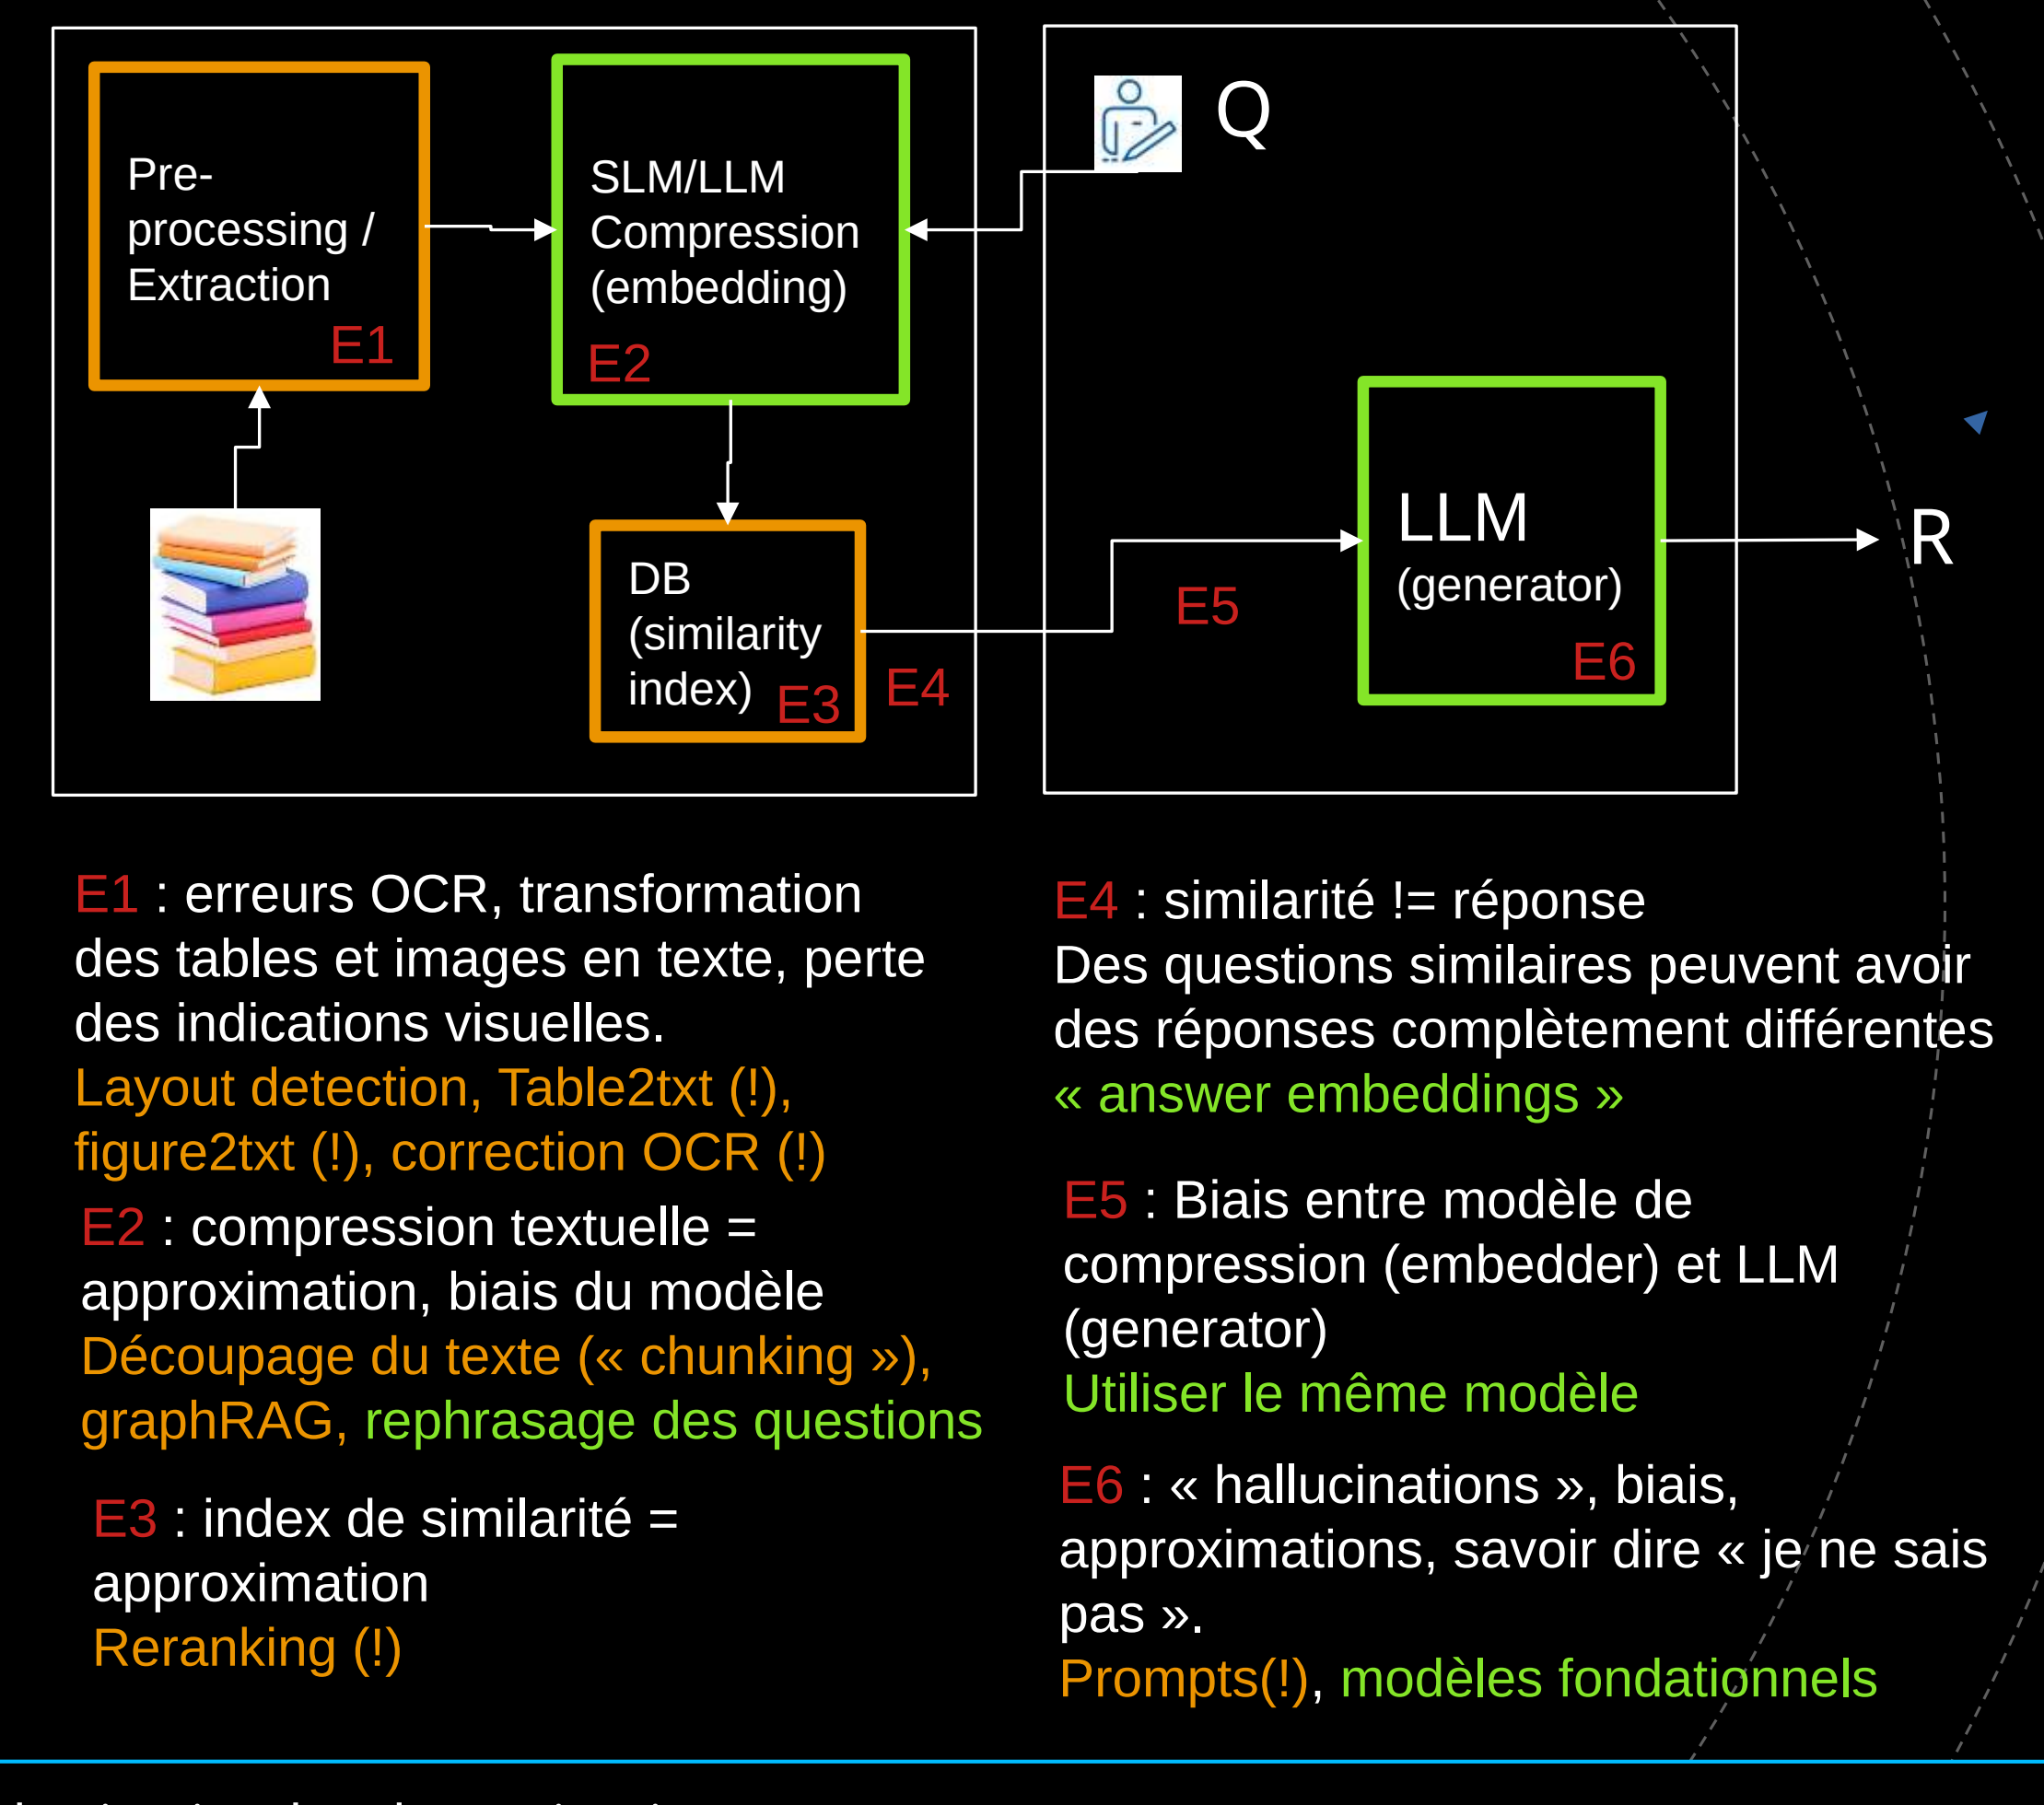

Image size: (2219, 1960)
--------------------------------------------------
Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0006_crop_0002
Distance: 0.8287726044654846
crop_label: text


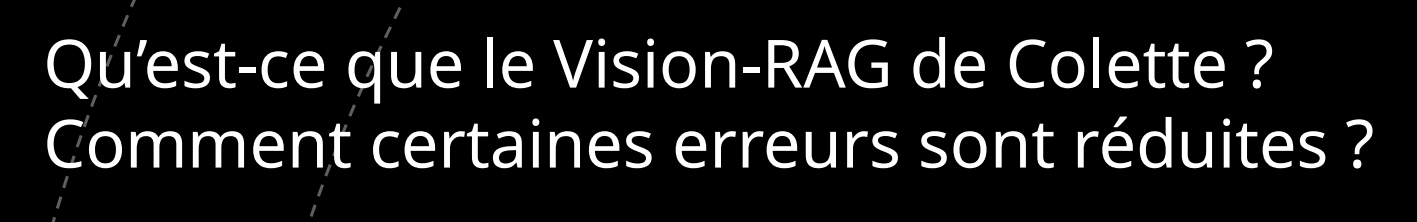

Image size: (1417, 222)
--------------------------------------------------
Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0004_crop_0002
Distance: 0.7929397225379944
crop_label: text


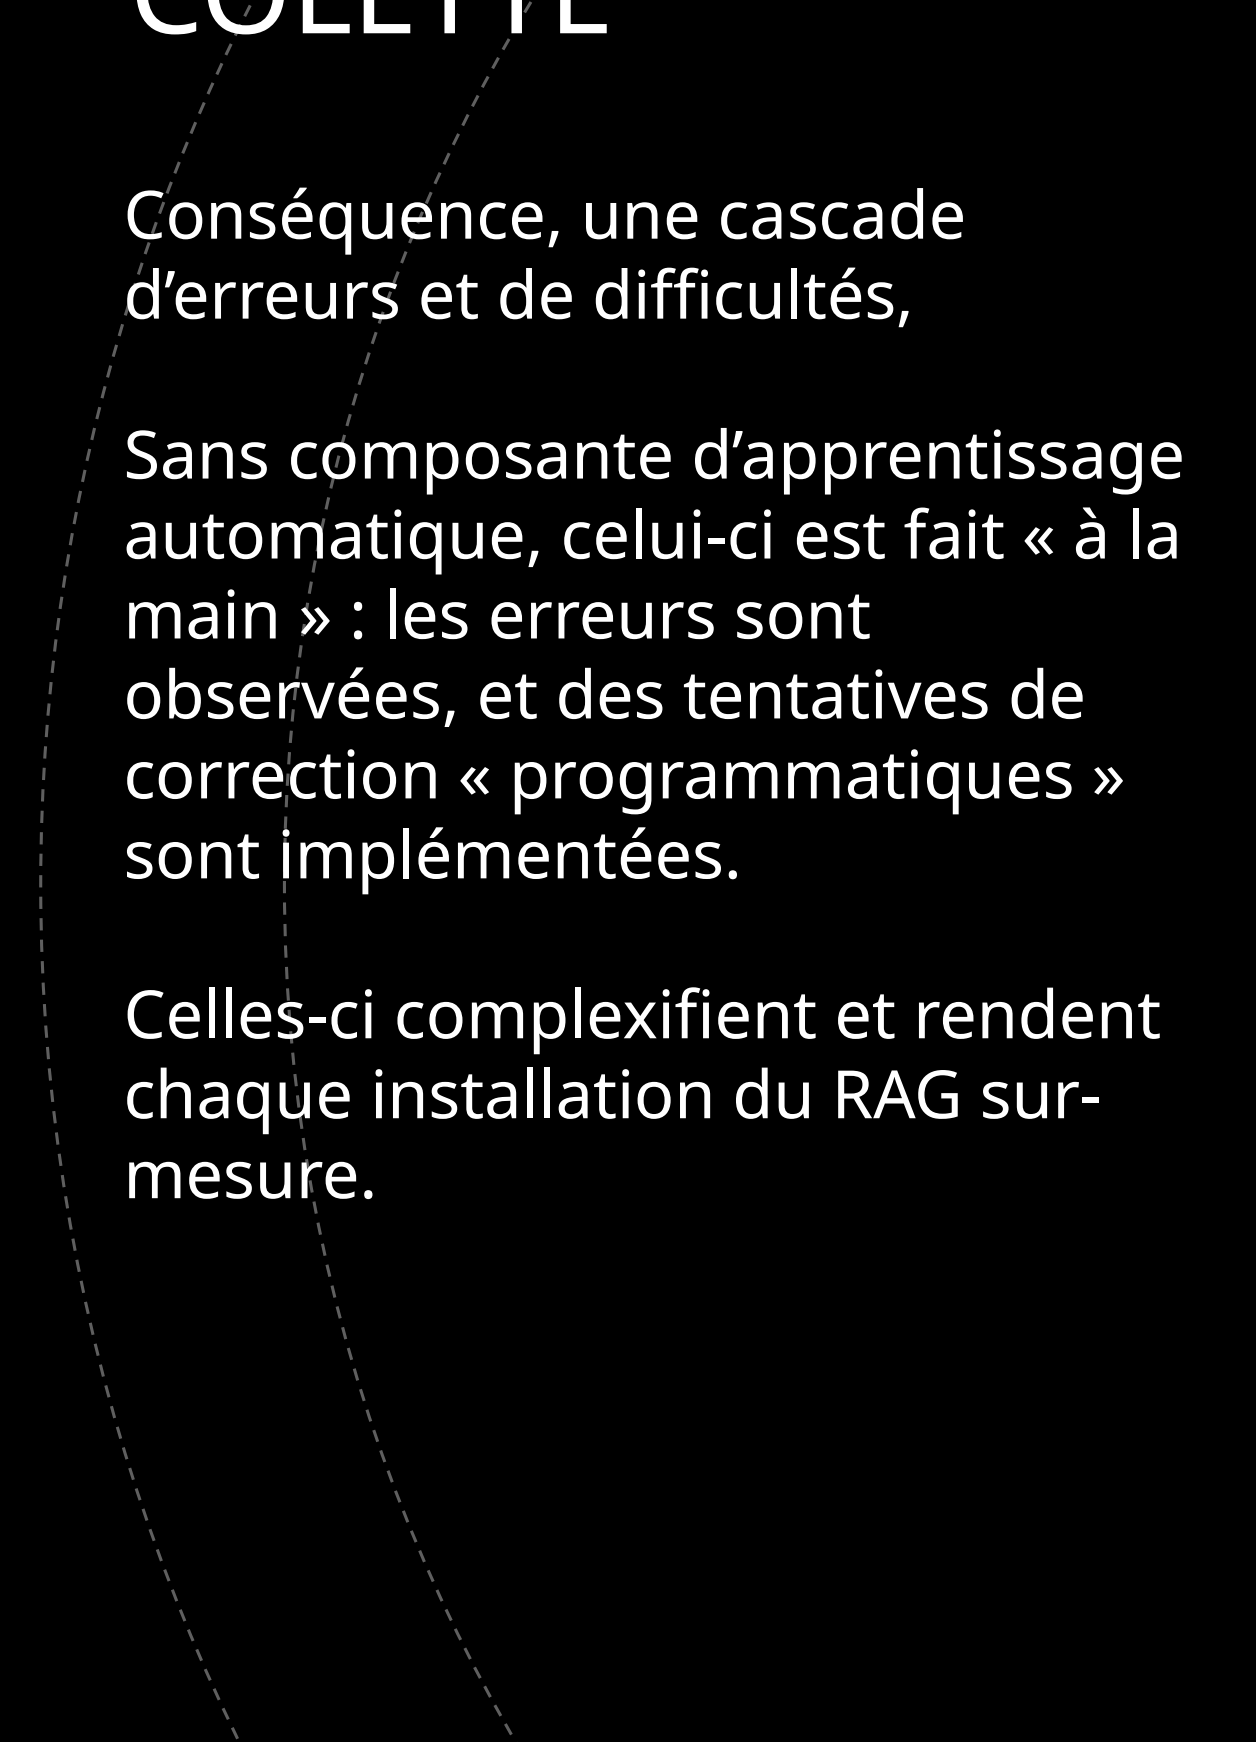

Image size: (1256, 1742)
--------------------------------------------------
Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0003_crop_0000
Distance: 0.7736433744430542
crop_label: text


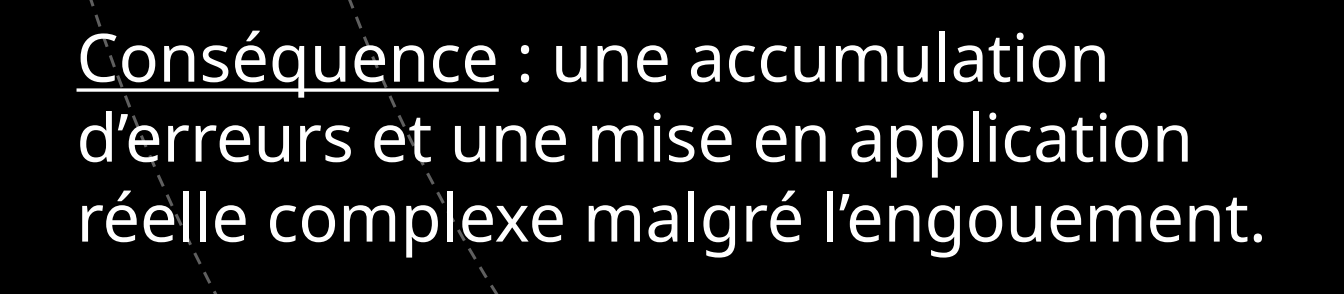

Image size: (1344, 294)
--------------------------------------------------


In [14]:
# Display all images in your context
for item in response.sources['context']:
    print(f"Key: {item['key']}")
    print(f"Distance: {item['distance']}")
    print(f'crop_label: {item.get("crop_label", "N/A")}')
    image = display_image_from_data_uri(item['content'])
    print(f"Image size: {image.size}")
    print("-" * 50)

## Retrieval Modes: Embedding, Text Search, and Hybrid

Colette supports three retrieval modes in `parameters.input.rag.retrieval_mode`:
- `embedding_retrieval`: visual embedding retrieval only (default) -> results in `sources['context']`
- `text_search_retrieval`: lexical text search (BM25) only -> results in `sources['text_context']`
- `hybrid`: combined retrieval -> results in both `sources['context']` and `sources['text_context']`

You can set this at index-time and override per request.


In [15]:
# The index above was already created with retrieval_mode='hybrid' (embedding + text search).
# There is no need to re-index - all three retrieval modes work against the same index.
#
# If you ever need to change the indexing mode later, you would call service_index again:
#   index_config_new_mode = json.loads(json.dumps(index_config))
#   index_config_new_mode['parameters']['input']['rag']['retrieval_mode'] = 'embedding_retrieval'
#   colette_api.service_index(app_name, APIData(**index_config_new_mode))
# Note: re-indexing recreates the ChromaDB collection, so the service must also be recreated
# afterwards to pick up the new collection reference.


In [16]:
# Example: per-request override to text-search only
# Only retrieval_mode is overridden; text_search_engine_* values come from JSON defaults
query_text_search = {
    'parameters': {
        'input': {
            'message': question,
            'rag': {
                'retrieval_mode': 'text_search_retrieval',
            }
        }
    }
}
response_text_search = colette_api.service_predict(app_name, APIData(**query_text_search))

2026-07-03 09:52:31,189 - api - INFO - predicting service with name: app_colette (jsonapi.py:268)
2026-07-03 09:52:31,190 - app_colette - INFO - Input transform and document retrieval took 0.00 seconds (hflib.py:72)
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
2026-07-03 09:52:51,932 - app_colette - INFO - LLM generation took 20.74 seconds (hflib.py:99)


In [17]:
print(response_text_search.output)

Based on the provided text from the COLETTE project, the identified sources of errors are not listed as specific categories (e.g., "network latency" or "data corruption"). Instead, the document frames the **minimization of all error sources** as a primary objective.

The specific points regarding errors found in the text are:

*   **General Error Sources:** The project explicitly aims to **"Amenuiser autant que possible l'ensemble des sources d'erreur"** (Minimize as much as possible the entire set of error sources). This implies that errors can originate from any stage of the pipeline, including:
    *   **Pre-processing / Extraction:** Converting documents into images.
    *   **Compression (embedding):** Processing the visual data.
    *   **Similarity Indexing (DB):** Retrieving relevant documents.
    *   **Generation:** The final output produced by the V-LLM.
*   **Accuracy Requirements:** The text highlights a need for a **"Garantie d'exactitude"** (Guarantee of accuracy), sugge

In [18]:
# With retrieval_mode='text_search_retrieval', embedding retrieval is skipped - sources['context'] is empty.
# Text search results are in sources['text_context'] instead.
for hit in response_text_search.sources.get('text_context', []):
    print(f"source: {hit['source']}")
    print(f"page: {hit.get('page_number')}")
    print(f"score: {hit.get('score', 'n/a'):.3f}")
    print(hit['content'][:200].replace('\n', ' '))
    print("-" * 50)


source: /data1/ldejesus/repos/public/colette_demo_gaia_converter/docs/pdf/COLETTEv2_Restitution_2025_03_07_v0.3_JB_light.pdf
page: 6
score: 2.712
6 COLETTE Objectifs pour Colette Amenuiser autant que possible  l’ensemble des sources d’erreur Rendre le RAG « paramétrique » de  bout en bout (cad. « apprenable ») ●Garantie d’exactitude et de  fo
--------------------------------------------------


In [19]:
# If retrieval_mode includes text search, inspect text_context in sources
response_hybrid = colette_api.service_predict(
    app_name,
    APIData(**{'parameters': {'input': {'message': 'What are the identified sources of errors ?', 'rag': {'retrieval_mode': 'hybrid'}}}})
)
for hit in response_hybrid.sources.get('text_context', []):
    print(f"{hit['source']} page {hit.get('page_number')} score={hit.get('score', 'n/a')}")
    print(hit['content'][:200])
    print()


2026-07-03 09:52:51,965 - api - INFO - predicting service with name: app_colette (jsonapi.py:268)
2026-07-03 09:52:52,020 - app_colette - INFO - Input transform and document retrieval took 0.05 seconds (hflib.py:72)
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
2026-07-03 09:53:18,111 - app_colette - INFO - LLM generation took 26.09 seconds (hflib.py:99)


/data1/ldejesus/repos/public/colette_demo_gaia_converter/docs/pdf/COLETTEv2_Restitution_2025_03_07_v0.3_JB_light.pdf page 6 score=2.7120752334594727
6
COLETTE
Objectifs pour Colette
Amenuiser autant que possible 
l’ensemble des sources d’erreur
Rendre le RAG « paramétrique » de 
bout en bout (cad. « apprenable »)
●Garantie d’exactitude et de 
fo



In [20]:
print(response_hybrid.output)

Based on the provided documents, the identified sources of errors in the Colette system (specifically the initial "hand-made" version) are:

1.  **OCR Errors:** Errors in Optical Character Recognition.
2.  **Table and Image Transformation:** Issues when transforming tables and images into text.
3.  **Loss of Visual Indications:** Loss of visual cues or indications present in the original document.
4.  **Layout Detection Errors:** Mistakes in detecting the layout of the document.
5.  **Text Chunking Errors:** Errors related to the "chunking" (segmentation) of the text.
6.  **GraphRAG Errors:** Errors associated with the GraphRAG component.
7.  **Question Rephrasing Errors:** Errors in the rephrasing of questions.
8.  **Similarity Index Errors:** Errors in the similarity index used for retrieval.
9.  **Compression Errors:** Errors in the compression of the text.
10. **Model Bias:** Bias inherent in the model.
11. **Hallucinations:** The generation of false or misleading information by th

In [21]:
for hit in response_hybrid.sources.get('text_context', []):
    print(f"source: {hit['source']}")
    print(f"page: {hit.get('page_number')}")
    print(f"score: {hit.get('score', 'n/a'):.3f}")
    print(hit['content'][:200].replace('\n', ' '))
    print("-" * 50)

source: /data1/ldejesus/repos/public/colette_demo_gaia_converter/docs/pdf/COLETTEv2_Restitution_2025_03_07_v0.3_JB_light.pdf
page: 6
score: 2.712
6 COLETTE Objectifs pour Colette Amenuiser autant que possible  l’ensemble des sources d’erreur Rendre le RAG « paramétrique » de  bout en bout (cad. « apprenable ») ●Garantie d’exactitude et de  fo
--------------------------------------------------


Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0004_crop_0000
Distance: 0.8363239169120789
crop_label: table


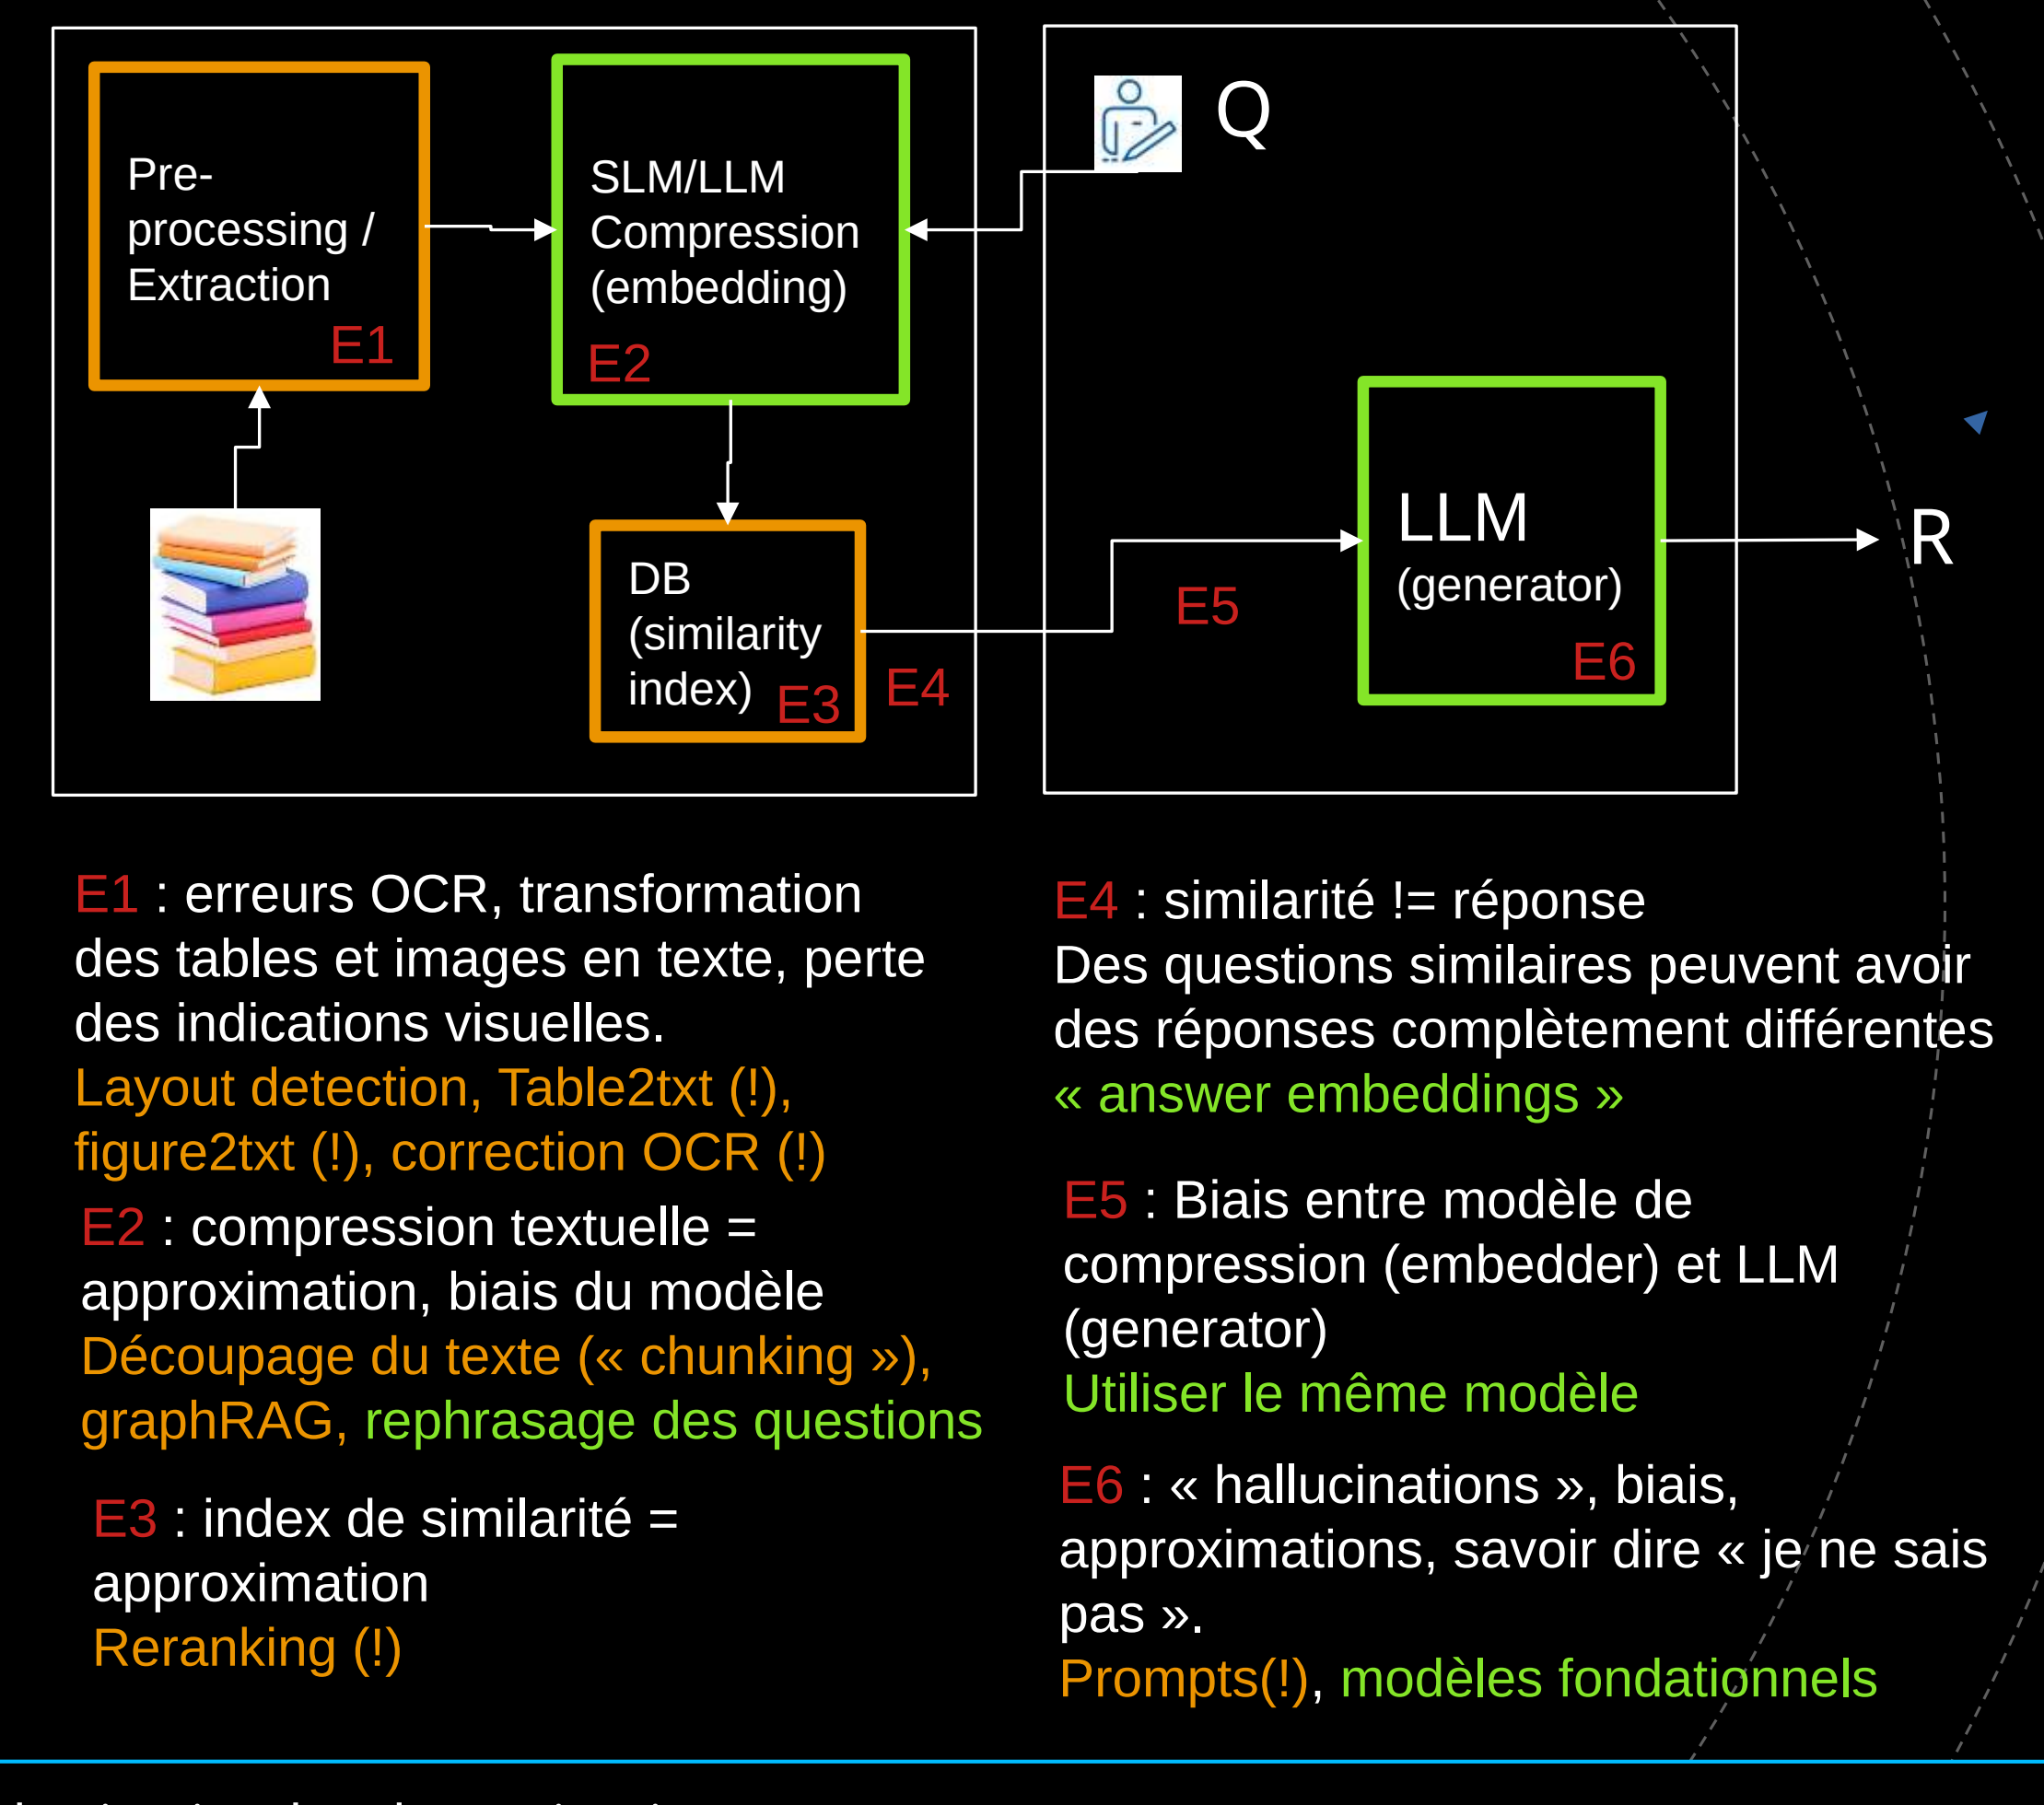

Image size: (2219, 1960)
--------------------------------------------------
Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0006_crop_0002
Distance: 0.8287726044654846
crop_label: text


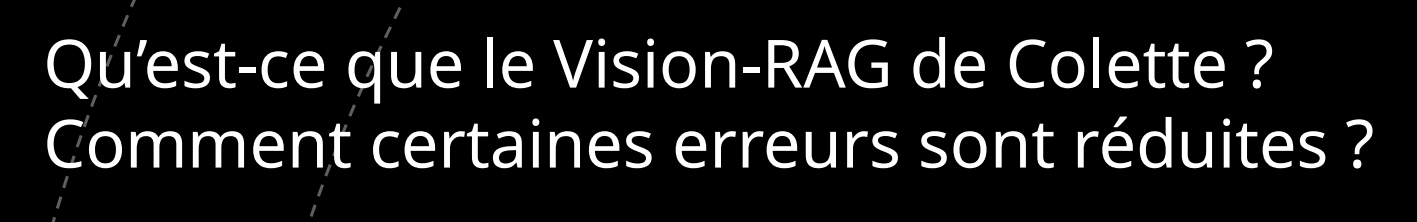

Image size: (1417, 222)
--------------------------------------------------
Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0004_crop_0002
Distance: 0.7929397225379944
crop_label: text


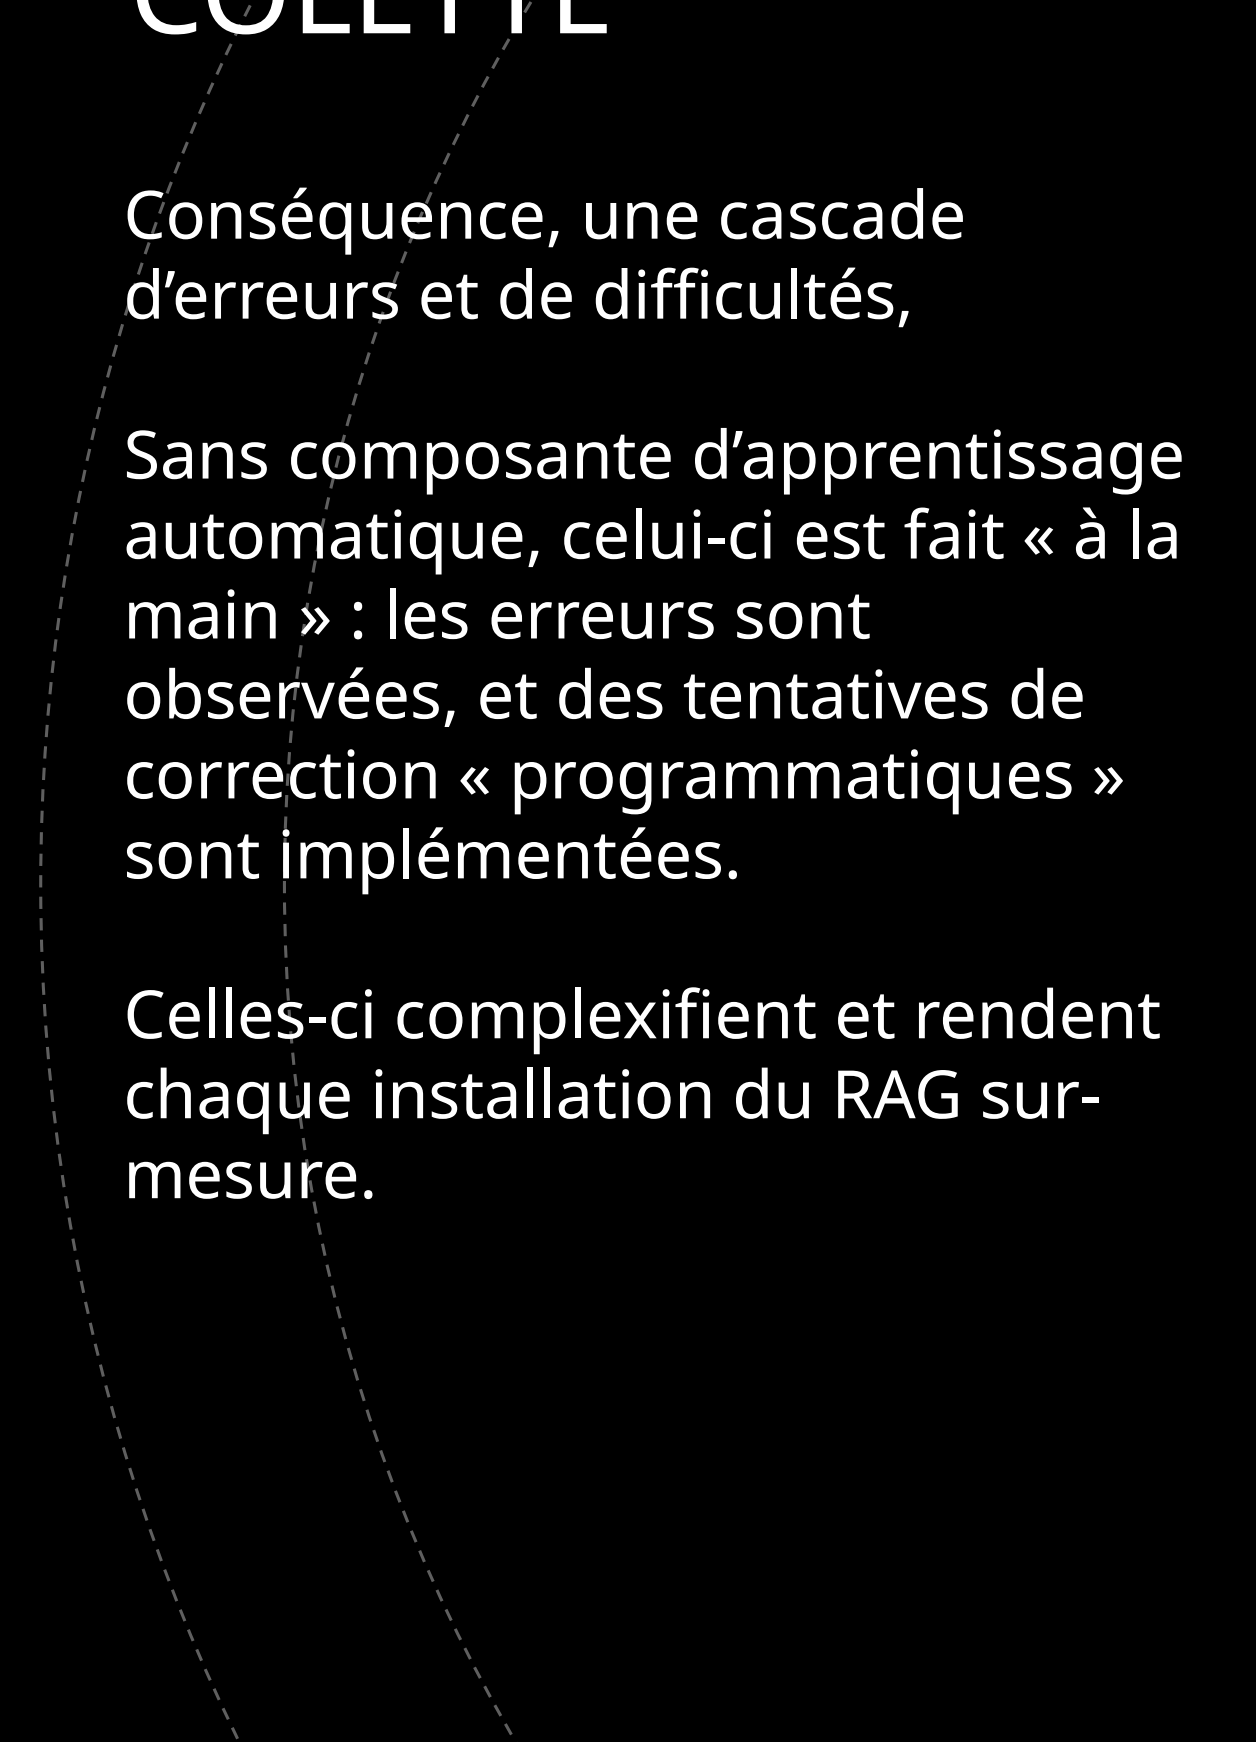

Image size: (1256, 1742)
--------------------------------------------------
Key: ef77f2b6-12d2-5fdf-a268-8aa09a7cb8b5_0003_crop_0000
Distance: 0.7736433744430542
crop_label: text


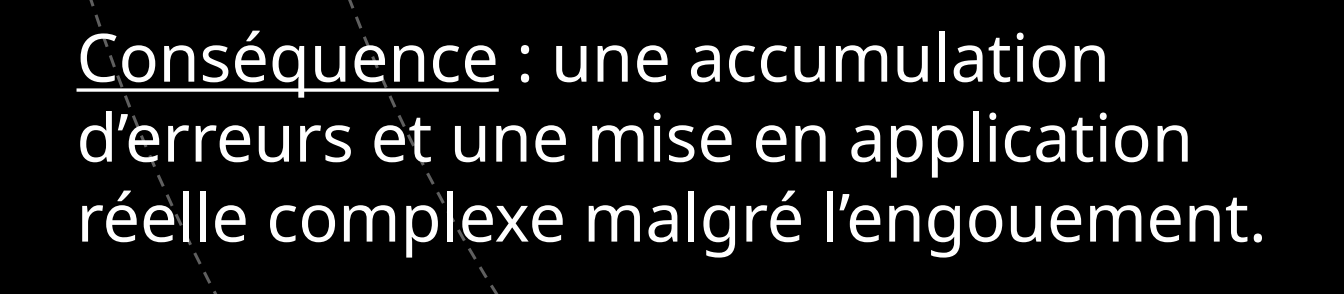

Image size: (1344, 294)
--------------------------------------------------


In [22]:
# Display all images in your context
for item in response_hybrid.sources['context']:
    print(f"Key: {item['key']}")
    print(f"Distance: {item['distance']}")
    print(f'crop_label: {item.get("crop_label", "N/A")}')
    image = display_image_from_data_uri(item['content'])
    print(f"Image size: {image.size}")
    print("-" * 50)

In [23]:
# Run this before restarting the kernel to safely flush and close kvstore.db
await colette_api.service_delete(app_name)

2026-07-03 09:53:18,580 - api - INFO - deleting service with name: app_colette (jsonapi.py:260)


APIResponse(version=None, status_code=None, status=StatusObj(code=200, status='OK', colette_code=None, colette_message=None), info=None, service_name=None, full_prompt=None, full_response=None, sources=None, message=None, output=None)